# EDA - Complete Blood Count (CBC)

**Nguồn:** `Dataset/Data/CBC.csv` (NHANES-style Complete Blood Count)

**Kích thước:** 9,165 dòng × 21 cột (1 ID + 20 chỉ số sinh huyết)

**Nhãn bệnh:** Không có cột target/label trong dataset hiện tại.

---

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [12]:
df = pd.read_csv("../Data/CBC.csv")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head(5)

Shape: 9165 rows × 21 columns
Columns: ['SEQN', 'LBXWBCSI', 'LBXLYPCT', 'LBXMOPCT', 'LBXNEPCT', 'LBXEOPCT', 'LBXBAPCT', 'LBDLYMNO', 'LBDMONO', 'LBDNENO', 'LBDEONO', 'LBDBANO', 'LBXRBCSI', 'LBXHGB', 'LBXHCT', 'LBXMCVSI', 'LBXMCHSI', 'LBXMC', 'LBXRDW', 'LBXPLTSI', 'LBXMPSI']


,SEQN,LBXWBCSI,LBXLYPCT,LBXMOPCT,LBXNEPCT,LBXEOPCT,LBXBAPCT,LBDLYMNO,LBDMONO,LBDNENO,...,LBDBANO,LBXRBCSI,LBXHGB,LBXHCT,LBXMCVSI,LBXMCHSI,LBXMC,LBXRDW,LBXPLTSI,LBXMPSI
0,83732.0,9.8,23.9,8.2,63.5,4.0,0.5,2.3,0.8,6.2,...,5.397605e-79,4.93,15.2,44.7,90.8,30.8,34.0,13.9,181.0,8.3
1,83733.0,7.3,31.3,9.7,54.8,2.6,1.8,2.3,0.7,4.0,...,1.000000e-01,4.89,17.5,49.7,101.8,35.8,35.1,13.4,170.0,9.6
2,83734.0,4.4,29.9,9.6,55.8,3.9,0.9,1.3,0.4,2.5,...,5.397605e-79,4.18,12.4,37.9,90.8,29.6,32.6,14.7,223.0,9.0
3,83735.0,6.1,17.1,10.3,68.7,3.1,0.9,1.0,0.6,4.2,...,1.000000e-01,4.54,12.8,40.1,88.3,28.2,31.9,13.1,280.0,9.1
4,83736.0,4.2,47.1,7.8,44.8,0.2,0.2,2.0,0.3,1.9,...,5.397605e-79,4.16,12.1,36.5,87.8,29.1,33.2,12.3,275.0,7.7


In [13]:
# Kiểm tra dữ liệu và missing values
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values (NaN) ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "Pct": missing_pct})
print(missing_df[missing_df["Missing"] > 0])

=== Data Types ===
SEQN        float64
LBXWBCSI    float64
LBXLYPCT    float64
LBXMOPCT    float64
LBXNEPCT    float64
LBXEOPCT    float64
LBXBAPCT    float64
LBDLYMNO    float64
LBDMONO     float64
LBDNENO     float64
LBDEONO     float64
LBDBANO     float64
LBXRBCSI    float64
LBXHGB      float64
LBXHCT      float64
LBXMCVSI    float64
LBXMCHSI    float64
LBXMC       float64
LBXRDW      float64
LBXPLTSI    float64
LBXMPSI     float64
dtype: object

=== Missing Values (NaN) ===
          Missing    Pct
LBXWBCSI     1048  11.43
LBXLYPCT     1049  11.45
LBXMOPCT     1049  11.45
LBXNEPCT     1049  11.45
LBXEOPCT     1049  11.45
LBXBAPCT     1049  11.45
LBDLYMNO     1049  11.45
LBDMONO      1049  11.45
LBDNENO      1049  11.45
LBDEONO      1049  11.45
LBDBANO      1049  11.45
LBXRBCSI     1048  11.43
LBXHGB       1048  11.43
LBXHCT       1048  11.43
LBXMCVSI     1048  11.43
LBXMCHSI     1048  11.43
LBXMC        1018  11.11
LBXRDW       1048  11.43
LBXPLTSI     1048  11.43
LBXMPSI      1048

In [14]:
# Trùng lặp  
duplicates = df.duplicated().sum()
print(f"Số dòng trùng lặp hoàn toàn: {duplicates}")

if duplicates > 0:
    dup_rows = df[df.duplicated(keep=False)]
    print(f"Số dòng bị ảnh hưởng: {len(dup_rows)}")
else:
    print("Không có dòng trùng lặp.")

Số dòng trùng lặp hoàn toàn: 0
Không có dòng trùng lặp.


## 4. Kiểm tra giá trị artifact & vô lý sinh học

In [15]:
# 4. Kiểm tra giá trị artifact & vô lý sinh học
# 4.1 Artifact detection (placeholder values like 5.3976e-79)
artifact_val = 5.397605346934028e-79
artifact_counts = {}
for col in df.columns:
    if df[col].dtype in ["float64", "int64"]:
        count = (df[col] == artifact_val).sum()
        if count > 0:
            artifact_counts[col] = count

print("=== Artifact Values (5.397605346934028e-79) ===")
if artifact_counts:
    for col, cnt in sorted(artifact_counts.items(), key=lambda x: -x[1]):
        print(f"  {col}: {cnt} ({cnt/len(df)*100:.1f}%)")
else:
    print("  Không phát hiện artifact.")

=== Artifact Values (5.397605346934028e-79) ===
  LBDBANO: 3856 (42.1%)
  LBDEONO: 411 (4.5%)
  LBXEOPCT: 17 (0.2%)


In [16]:
# 4.2 Biological range validation (adult reference ranges)
biological_ranges = {
    "LBXWBCSI": (4.5, 11.0),      # WBC (10^3/uL)
    "LBXLYPCT": (20.0, 40.0),     # Lymphocyte %
    "LBXMOPCT": (2.0, 8.0),       # Monocyte %
    "LBXNEPCT": (40.0, 60.0),     # Neutrophil %
    "LBXEOPCT": (1.0, 4.0),       # Eosinophil %
    "LBXBAPCT": (0.5, 1.0),       # Basophil %
    "LBDLYMNO": (1.0, 3.0),       # Lymphocyte count (10^3/uL)
    "LBDMONO": (0.2, 0.8),        # Monocyte count
    "LBDNENO": (1.8, 7.0),        # Neutrophil count
    "LBDEONO": (0.0, 0.5),        # Eosinophil count
    "LBDBANO": (0.0, 0.2),        # Basophil count
    "LBXRBCSI": (4.0, 5.5),       # RBC (10^6/uL)
    "LBXHGB": (12.0, 17.5),       # Hemoglobin (g/dL)
    "LBXHCT": (36.0, 50.0),       # Hematocrit (%)
    "LBXMCVSI": (80.0, 100.0),    # MCV (fL)
    "LBXMCHSI": (27.0, 31.0),     # MCH (pg)
    "LBXMC": (32.0, 36.0),        # MCHC (g/dL)
    "LBXRDW": (11.5, 14.5),       # RDW (%)
    "LBXPLTSI": (150.0, 400.0),   # Platelets (10^3/uL)
    "LBXMPSI": (7.5, 11.5)        # MPV (fL)
}

print("=== Biological Outliers ===")
outlier_summary = {}
for col, (low, high) in biological_ranges.items():
    if col in df.columns:
        valid = df[col].dropna()
        valid = valid[valid != artifact_val]  # exclude artifact
        if len(valid) == 0:
            continue
        outliers = valid[(valid < low) | (valid > high)]
        outlier_summary[col] = {
            "min": valid.min(),
            "max": valid.max(),
            "outliers": len(outliers),
            "outlier_pct": len(outliers) / len(valid) * 100
        }

for col, info in sorted(outlier_summary.items(), key=lambda x: -x[1]["outlier_pct"]):
    print(f"  {col}: range [{info['min']:.2f}, {info['max']:.2f}], outliers={info['outliers']} ({info['outlier_pct']:.1f}%)")

=== Biological Outliers ===
  LBXMOPCT: range [1.40, 29.30], outliers=3765 (46.4%)
  LBXNEPCT: range [3.60, 93.20], outliers=3445 (42.4%)
  LBXMCHSI: range [13.80, 38.50], outliers=2880 (35.5%)
  LBXLYPCT: range [3.70, 94.50], outliers=2588 (31.9%)
  LBXEOPCT: range [0.10, 32.20], outliers=2547 (31.4%)
  LBXBAPCT: range [0.10, 4.00], outliers=2422 (29.8%)
  LBXMPSI: range [5.60, 15.10], outliers=1816 (22.4%)
  LBDLYMNO: range [0.20, 110.80], outliers=1772 (21.8%)
  LBXRDW: range [11.50, 26.40], outliers=1275 (15.7%)
  LBXMCVSI: range [50.80, 115.60], outliers=1188 (14.6%)
  LBXWBCSI: range [1.40, 117.20], outliers=965 (11.9%)
  LBXHCT: range [21.80, 59.10], outliers=940 (11.6%)
  LBXHGB: range [6.20, 19.20], outliers=920 (11.3%)
  LBDNENO: range [0.30, 19.40], outliers=819 (10.1%)
  LBXRBCSI: range [2.52, 7.90], outliers=804 (9.9%)
  LBDMONO: range [0.10, 2.60], outliers=783 (9.6%)
  LBXMC: range [27.10, 36.60], outliers=654 (8.0%)
  LBXPLTSI: range [14.00, 777.00], outliers=496 (6.1%)

In [17]:
# Phân bổ nhãn
label_cols = [c for c in df.columns if "disease" in c.lower() or "label" in c.lower() or "target" in c.lower()]
if label_cols:
    print(f"Tìm thấy cột nhãn: {label_cols}")
    for col in label_cols:
        print(f"\nPhân bố {col}:")
        print(df[col].value_counts())
else:
    print("Dataset KHÔNG có cột nhãn bệnh (target/label).")
    print("Cần merge với dataset khác (ví dụ: Laboratory Data hoặc Personalized Medication) để có nhãn cho modeling.")

Dataset KHÔNG có cột nhãn bệnh (target/label).
Cần merge với dataset khác (ví dụ: Laboratory Data hoặc Personalized Medication) để có nhãn cho modeling.


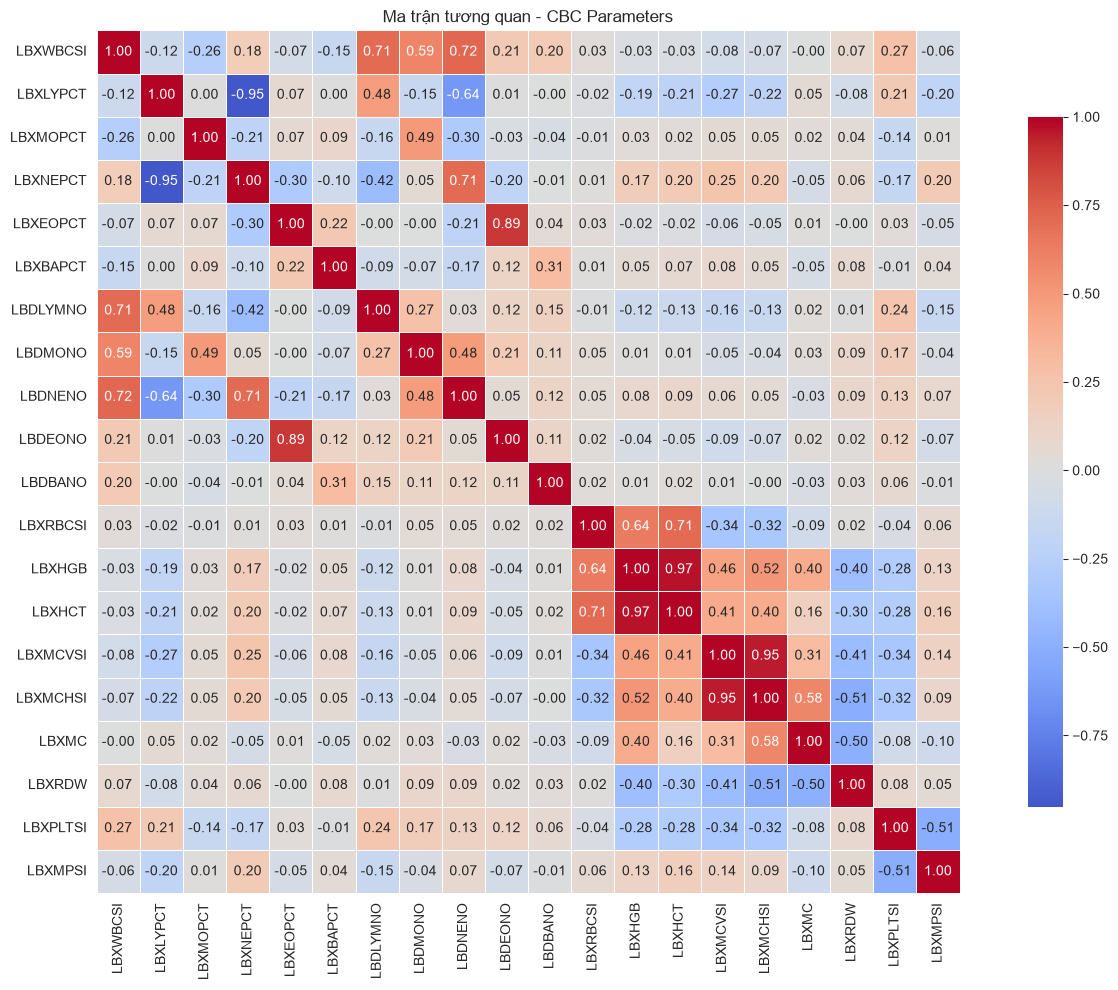

In [18]:
# Ma trận tương quan 
# Prepare numeric data excluding artifact and ID
numeric_df = df.drop(columns=["SEQN"])
numeric_df = numeric_df.replace(artifact_val, np.nan)
numeric_df = numeric_df.apply(pd.to_numeric, errors="coerce")

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Ma trận tương quan - CBC Parameters")
plt.tight_layout()
plt.show()

In [19]:
desc = numeric_df.describe().T
desc["missing_pct"] = (df.drop(columns=["SEQN"]).isnull().sum() / len(df) * 100).round(2)
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "missing_pct"]]
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,missing_pct
LBXWBCSI,8117.0,7.43,2.58,1.40,5.90,7.10,8.60,117.2,11.43
LBXLYPCT,8116.0,34.15,10.66,3.70,26.90,32.90,40.10,94.5,11.45
LBXMOPCT,8116.0,8.16,2.18,1.40,6.70,7.90,9.30,29.3,11.45
LBXNEPCT,8116.0,53.96,11.37,3.60,47.10,55.10,61.70,93.2,11.45
LBXEOPCT,8099.0,3.09,2.45,0.10,1.60,2.40,3.80,32.2,11.45
LBXBAPCT,8116.0,0.78,0.32,0.10,0.60,0.70,1.00,4.0,11.45
LBDLYMNO,8116.0,2.51,1.69,0.20,1.80,2.30,2.90,110.8,11.45
LBDMONO,8116.0,0.59,0.20,0.10,0.50,0.60,0.70,2.6,11.45
LBDNENO,8116.0,4.06,1.69,0.30,2.90,3.80,4.90,19.4,11.45
LBDEONO,7705.0,0.24,0.20,0.10,0.10,0.20,0.30,4.5,11.45


### Phát hiện chính

- **Artifact kỹ thuật:** Giá trị `5.397605346934028e-79` xuất hiện ở hàng loạt cột (~43% dòng), đây là placeholder hệ thống cần thay thế bằng `NaN` trước khi phân tích.
- **Missing data:** ~11.4% dòng thiếu ở hầu hết các cột; một số cột như `LBXMC` có tỷ lệ missing thấp hơn.
- **Trùng lặp:** Không có dòng trùng lặp hoàn toàn.
- **Outlier sinh học:** Hầu hết các chỉ số đều có outlier nằm ngoài range tham khảo; cần review lâm sàng trước khi loại bỏ.
- **Tương quan:** Các chỉ số cùng nhóm có tương quan cao (ví dụ: HGB-HCT, MCV-MCH, WBC-Neutrophil).

### Khuyến nghị Cleaning

1. **Thay thế artifact:** toàn bộ `5.397605346934028e-79` → `NaN`.
2. **Ép kiểu numeric:** dùng `pd.to_numeric(errors='coerce')` để bắt giá trị không hợp lệ.
3. **Outlier strategy:** không xóa vội; dùng flag/biến nhị phân đánh dấu outlier thay vì loại bỏ.
4. **Imputation:** cân nhắc MICE/KNN do tương quan cao giữa các chỉ số CBC.
5. **Label:** merge với dataset có nhãn bệnh để tiếp tục modeling.